In [20]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec
import itertools

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_mask_distributions, plot_metric_vs_lambda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

In [22]:
def find_switch_accuracy(row):
    switch_accuracy = (row['binary_mask'][:,-1] == row['g_test'][:,-1]).mean()
    return switch_accuracy

### Tuning SHAP

In [8]:
shap = load_results_from_pickle(folder='ICML_experiments/correlated/tuning/xgboost',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['rho','lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (shap.num_syn_features == 11).all()

shap['F1'] = shap.apply(compute_rowwise_metrics, axis=1)

shap = shap.query('syn != "Syn7"')
shap['switch_accuracy'] = shap.apply(lambda row: find_switch_accuracy(row),axis=1)

In [9]:
shap['config_tuple'] = shap['xgb_params'].apply(lambda x: tuple(sorted(x.items())))
shap['config_id'] = shap['config_tuple'].factorize()[0]

- 64 combinations of xgb_params
- each rho has one for each of the 6 syn datasets

In [10]:
cols = ['rho', 'lmbda', 'roc_auc', 'pr_auc', 'pct_sig', 'f1', 'TPR_mean', 'FDR_mean', 'config_id']

# 1. Group by both rho and config_id, then calculate the mean for the remaining columns
mean_shap = shap[cols].groupby(['rho', 'config_id'], as_index=False).mean()

# 2. Sort by roc_auc descending, then drop duplicate rhos to keep the absolute best per rho
shap_best_configs_per_rho = (
    mean_shap.sort_values('roc_auc', ascending=False)
             .drop_duplicates(subset=['rho'])
             .sort_values('rho') # Optional: sort by rho to make it readable
             .reset_index(drop=True)
)

configs_map = shap[['config_id','config_tuple','model']].drop_duplicates()

shap_best_configs_per_rho = shap_best_configs_per_rho.merge(configs_map, on ='config_id').sort_values(by='rho')
shap_best_configs_per_rho

,rho,config_id,lmbda,roc_auc,pr_auc,pct_sig,f1,TPR_mean,FDR_mean,config_tuple,model
0,0.0,26,0.3,0.824250,0.834529,0.378788,75.636833,78.243500,25.927167,"((colsample_bytree, 0.9), (eta, 0.1), (eval_me...",SHAP
1,0.1,27,0.3,0.823692,0.831929,0.378788,77.181083,79.832194,24.409583,"((colsample_bytree, 1.0), (eta, 0.1), (eval_me...",SHAP
2,0.2,23,0.3,0.826445,0.827944,0.378788,81.334750,84.100722,20.324833,"((colsample_bytree, 1.0), (eta, 0.05), (eval_m...",SHAP
4,0.3,22,0.3,0.829271,0.830793,0.378788,81.488417,84.068416,20.059583,"((colsample_bytree, 0.9), (eta, 0.05), (eval_m...",SHAP
5,0.4,22,0.3,0.826953,0.826621,0.378788,81.069167,83.920416,20.641583,"((colsample_bytree, 0.9), (eta, 0.05), (eval_m...",SHAP
6,0.5,22,0.3,0.831806,0.831563,0.378788,83.611500,86.713583,18.249750,"((colsample_bytree, 0.9), (eta, 0.05), (eval_m...",SHAP
7,0.6,22,0.3,0.831180,0.825443,0.378788,82.913917,86.137805,19.020417,"((colsample_bytree, 0.9), (eta, 0.05), (eval_m...",SHAP
8,0.7,22,0.3,0.834789,0.827707,0.378788,82.931167,86.188250,19.023083,"((colsample_bytree, 0.9), (eta, 0.05), (eval_m...",SHAP
3,0.8,23,0.3,0.839611,0.827750,0.378788,82.959250,86.394944,19.102167,"((colsample_bytree, 1.0), (eta, 0.05), (eval_m...",SHAP
9,0.9,10,0.3,0.843949,0.830194,0.378788,81.044000,84.535250,21.050750,"((colsample_bytree, 0.9), (eta, 0.1), (eval_me...",SHAP


In [11]:
for i in range(6):
    print(shap_best_configs_per_rho['config_tuple'].iloc[i])

(('colsample_bytree', 0.9), ('eta', 0.1), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))
(('colsample_bytree', 1.0), ('eta', 0.1), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))
(('colsample_bytree', 1.0), ('eta', 0.05), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))
(('colsample_bytree', 0.9), ('eta', 0.05), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))
(('colsample_bytree', 0.9), ('eta', 0.05), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))
(('colsample_bytree', 0.9), ('eta', 0.05), ('eval_metric', 'logloss'), ('max_depth', 5), ('num_boost_round', 100), ('objective', 'binary:logistic'), ('seed', 0))


### Tuning Hide&Seek, REAL-x, INVASE

In [12]:
from loading_runs import load_pickle

In [13]:
temp = load_results_from_pickle(folder='ICML_experiments/correlated/tuning',
                                        time_threshold='25_09_03_12_00_00',#"25_07_08_14_00_00",
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['rho','lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp = temp.query('syn != "Syn7"')
temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)
temp = temp.query('model!="Hide&Seek_ens"')
temp = temp.query('lmbda!=0.7')

In [14]:
temp.groupby(['model','lmbda'])[['syn','TPR_mean','FDR_mean','f1']].count()

syn  TPR_mean  FDR_mean  f1
model     lmbda                             
Hide&Seek 0.05    66        66        66  66
          0.10    66        66        66  66
          0.30    66        66        66  66
          0.50    66        66        66  66
INVASE    0.05    66        66        66  66
          0.10    66        66        66  66
          0.30    66        66        66  66
          0.50    66        66        66  66
L2X       0.10    66        66        66  66
LIME      0.10    66        66        66  66
REAL-x    0.05    66        66        66  66
          0.10    66        66        66  66
          0.30    66        66        66  66
          0.50    66        66        66  66

11 rhos for 6 synthetic datasets

In [15]:
a = temp.groupby(['model','rho','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean()
a[['roc_auc','pr_auc','pct_sig']].head(20)

roc_auc    pr_auc   pct_sig
model     rho lmbda                              
Hide&Seek 0.0 0.05   0.818962  0.828915  0.970632
              0.10   0.828386  0.839331  0.513483
              0.30   0.830877  0.841311  0.351526
              0.50   0.825717  0.835973  0.335317
          0.1 0.05   0.823721  0.830870  0.826989
              0.10   0.832168  0.838983  0.447712
              0.30   0.831391  0.837718  0.350105
              0.50   0.824886  0.830973  0.327133
          0.2 0.05   0.823501  0.825706  0.847171
              0.10   0.831666  0.833620  0.416752
              0.30   0.827631  0.829154  0.347282
              0.50   0.818422  0.820063  0.327747
          0.3 0.05   0.824246  0.824816  0.933870
              0.10   0.830518  0.831759  0.528329
              0.30   0.830978  0.832761  0.349942
              0.50   0.824318  0.825883  0.325171
          0.4 0.05   0.823689  0.822762  0.960474
              0.10   0.829809  0.829853  0.456808
              0.30   0.826961  0.825636  0.340279
              0.50   0.819250  0.817543  0.317455

- Tuning lambda for INVASE and REALx is very hard, as shown in tuning diagrams in the paper
- Hide&Seek should have a range of good values
- For Hide&Seek, a good principle seems to be the highest lambda that providdes roc_auc higher than 99% of the highest roc_auc
- For REAL-x, INVASE, it's much harder to see and subject to error. The best heuristic for this experiment would be to look within the lambdas that result in 20 to 50% important features (we know it is around 30-40) and take the lambda giving the highest roc_auc in that range
- In other experiments, there was simply one ROC_AUC vs lmbda graph to look at. Here there would be 11 separate experiments, so we need some kind of heuristic.

- Two options. Either just pick the best ROC_AUC. Or do the separate treatment. In the paper, we show the separate treatment. Here we also show the result when simply the highest ROC_AUC is selected.

### Separate treatment

Hide&Seek

In [23]:
def pick_lambda_within_tol(df, tol_pct=0.99):
    best = df['roc_auc'].max()
    threshold = tol_pct * best
    
    # Keep rows within tolerance
    eligible = df[df['roc_auc'] >= threshold]
    
    # Sort by lmbda and pick the highest one
    return eligible.sort_values('lmbda').iloc[-1]

hs_tune = (
    a.query('model=="Hide&Seek"')
        .reset_index()
     .groupby(['model', 'rho'])
     .apply(pick_lambda_within_tol, tol_pct=0.99)
     .reset_index(drop=True)
)

hs_tune

,model,rho,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,Hide&Seek,0.0,0.5,94.771694,1.005444,96.089956,0.825717,0.835973,0.335317
1,Hide&Seek,0.1,0.5,93.293861,1.041984,95.359609,0.824886,0.830973,0.327133
2,Hide&Seek,0.2,0.3,97.921222,1.522199,98.031588,0.827631,0.829154,0.347282
3,Hide&Seek,0.3,0.5,92.851944,0.910429,94.991179,0.824318,0.825883,0.325171
4,Hide&Seek,0.4,0.3,96.584861,1.426157,97.299441,0.826961,0.825636,0.340279
5,Hide&Seek,0.5,0.3,94.236583,1.470871,95.596939,0.827076,0.827011,0.334685
6,Hide&Seek,0.6,0.1,98.551833,10.267064,92.898164,0.833372,0.827802,0.409403
7,Hide&Seek,0.7,0.1,98.122889,7.395858,94.494328,0.835421,0.829616,0.385623
8,Hide&Seek,0.8,0.1,95.240222,8.040767,93.068919,0.837203,0.824439,0.369056
9,Hide&Seek,0.9,0.1,87.003111,6.765272,88.673934,0.839661,0.827320,0.320024


INVASE, REAL-x

take the one with the highest roc_auc in 0.2 to 0.5. If none exist, take the one with highest roc_auc below 0.2.

In [24]:
models = ['INVASE', 'REAL-x']

realx_inv_tune = (
    a.query("model in @models and pct_sig <= 0.5") # Keep ideal AND fallback rows
     .assign(is_ideal=lambda df: df['pct_sig'] >= 0.2) # Flag the ones in the 0.2-0.5 range
     .sort_values(
         by=['model', 'rho', 'is_ideal', 'roc_auc'], 
         ascending=[True, True, False, False] # Sort 'is_ideal' and 'roc_auc' descending
     )
     .groupby(['model', 'rho'])
     .head(1) # Take the top row of each group
     .drop(columns=['is_ideal']) # Clean up the helper column
     .reset_index()
)

realx_inv_tune

,model,rho,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,INVASE,0.0,0.05,94.366222,14.837717,87.954439,0.783650,0.793847,0.410058
1,INVASE,0.1,0.30,65.815305,0.314595,72.296028,0.785143,0.793387,0.228602
2,INVASE,0.2,0.05,96.188889,12.471720,90.517775,0.783672,0.785972,0.403489
3,INVASE,0.3,0.10,92.564250,3.513121,93.626080,0.786482,0.788180,0.339565
4,INVASE,0.4,0.05,95.684889,15.905283,88.183357,0.790817,0.789322,0.420018
5,INVASE,0.5,0.10,95.732111,4.668224,94.902861,0.794225,0.795495,0.354961
6,INVASE,0.6,0.10,92.711444,6.088742,92.387090,0.797008,0.792558,0.351911
7,INVASE,0.7,0.10,79.637194,5.451679,84.702187,0.798838,0.797319,0.286226
8,INVASE,0.8,0.05,86.449333,21.748578,80.557300,0.807556,0.804077,0.415233
9,INVASE,0.9,0.05,77.302639,18.556007,75.199316,0.812780,0.808957,0.376998


In [25]:
tuning_values = pd.concat([hs_tune, 
                realx_inv_tune, 
                a.query('model=="L2X"').reset_index(),
                a.query('model=="LIME"').reset_index(),
                shap_best_configs_per_rho.drop(['config_id','config_tuple'],axis=1)])

tuning_dict = {
    model: g.set_index('rho')['lmbda'].to_dict()
    for model, g in tuning_values.groupby('model')
}
tuning_dict

{'Hide&Seek': {0.0: 0.5,
  0.1: 0.5,
  0.2: 0.3,
  0.3: 0.5,
  0.4: 0.3,
  0.5: 0.3,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.1,
  0.9: 0.1,
  1.0: 0.1},
 'INVASE': {0.0: 0.05,
  0.1: 0.3,
  0.2: 0.05,
  0.3: 0.1,
  0.4: 0.05,
  0.5: 0.1,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.05,
  0.9: 0.05,
  1.0: 0.05},
 'L2X': {0.0: 0.1,
  0.1: 0.1,
  0.2: 0.1,
  0.3: 0.1,
  0.4: 0.1,
  0.5: 0.1,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.1,
  0.9: 0.1,
  1.0: 0.1},
 'LIME': {0.0: 0.1,
  0.1: 0.1,
  0.2: 0.1,
  0.3: 0.1,
  0.4: 0.1,
  0.5: 0.1,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.1,
  0.9: 0.1,
  1.0: 0.1},
 'REAL-x': {0.0: 0.1,
  0.1: 0.1,
  0.2: 0.1,
  0.3: 0.1,
  0.4: 0.1,
  0.5: 0.05,
  0.6: 0.05,
  0.7: 0.05,
  0.8: 0.05,
  0.9: 0.05,
  1.0: 0.05},
 'SHAP': {0.0: 0.3,
  0.1: 0.3,
  0.2: 0.3,
  0.3: 0.3,
  0.4: 0.3,
  0.5: 0.3,
  0.6: 0.3,
  0.7: 0.3,
  0.8: 0.3,
  0.9: 0.3,
  1.0: 0.3}}

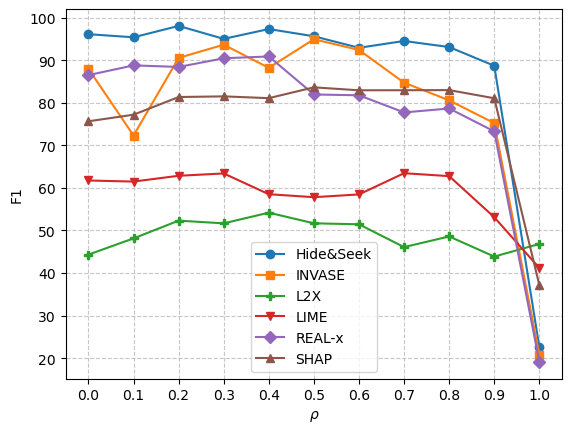

In [26]:
# Specify your desired path here
# save_path = os.path.join(os.path.abspath('..'), 'figures', 'correlated.pdf') 
# save_path = os.path.expanduser(save_path)

plt.figure() # Optional: makes the chart slightly wider and easier to read

markers = itertools.cycle(['o', 's', 'P','v', 'D', '^'])

for model, g in tuning_values.groupby('model'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers), 
        markersize=6, 
        label=model
    )

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

plt.xlabel(r'$\rho$')
plt.ylabel('F1')
plt.legend()

# 1. Force the x-axis ticks to be every 0.1 from 0 to 1
plt.xticks(np.arange(0, 1.1, 0.1)) 

# 2. Add grid lines (added styling makes it look a bit cleaner)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save as a PDF (bbox_inches='tight' prevents the labels from getting cut off)
# plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plot
plt.show()

we don't include $\rho = 1$ because feature importance is then meaningless. ie the not important features give as much info as the others. Also recall that shap, l2x and lime are all told the number of important features, so even in $\rho=1$ they still seek an extra feature.

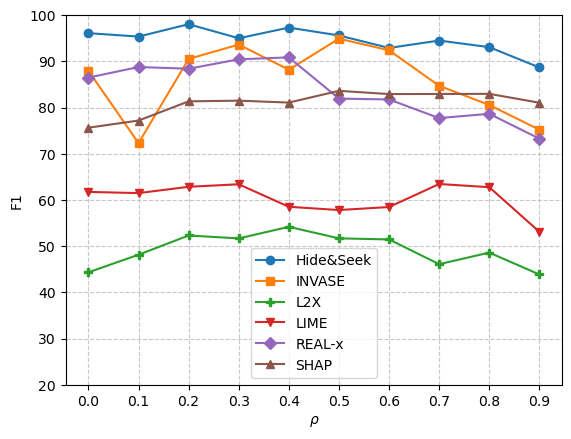

In [27]:
# Specify your desired path here
save_path = os.path.join(os.path.abspath('..'), 'figures', 'correlated.pdf') 
save_path = os.path.expanduser(save_path)

plt.figure() # Optional: makes the chart slightly wider and easier to read

markers = itertools.cycle(['o', 's', 'P','v', 'D', '^'])

for model, g in tuning_values.query('rho!=1').groupby('model'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers), 
        markersize=6, 
        label=model
    )

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

plt.xlabel(r'$\rho$')
plt.ylabel('F1')
plt.ylim(20,100)
plt.legend()

# 1. Force the x-axis ticks to be every 0.1 from 0 to 1
plt.xticks(np.arange(0, 1, 0.1)) 

# 2. Add grid lines (added styling makes it look a bit cleaner)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save as a PDF (bbox_inches='tight' prevents the labels from getting cut off)
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plot
plt.show()

switch accuracy for syn4,5,6

each rho for each model has 3 syns: 4,5,6. This give the mean switch accuracy across those syns.

In [166]:
tuning_values.query('model=="Hide&Seek"')

,model,rho,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,Hide&Seek,0.0,0.5,94.771694,1.005444,96.089956,0.825717,0.835973,0.335317
1,Hide&Seek,0.1,0.5,93.293861,1.041984,95.359609,0.824886,0.830973,0.327133
2,Hide&Seek,0.2,0.3,97.921222,1.522199,98.031588,0.827631,0.829154,0.347282
3,Hide&Seek,0.3,0.5,92.851944,0.910429,94.991179,0.824318,0.825883,0.325171
4,Hide&Seek,0.4,0.3,96.584861,1.426157,97.299441,0.826961,0.825636,0.340279
5,Hide&Seek,0.5,0.3,94.236583,1.470871,95.596939,0.827076,0.827011,0.334685
6,Hide&Seek,0.6,0.1,98.551833,10.267064,92.898164,0.833372,0.827802,0.409403
7,Hide&Seek,0.7,0.1,98.122889,7.395858,94.494328,0.835421,0.829616,0.385623
8,Hide&Seek,0.8,0.1,95.240222,8.040767,93.068919,0.837203,0.824439,0.369056
9,Hide&Seek,0.9,0.1,87.003111,6.765272,88.673934,0.839661,0.827320,0.320024


In [183]:
filtered_temp.query('model=="Hide&Seek" & rho ==0.9')

,model,rho,f1,lmbda,syn,switch_accuracy
150,Hide&Seek,0.9,100.000000,0.1,1,1.0000
151,Hide&Seek,0.9,93.546476,0.1,2,0.9988
152,Hide&Seek,0.9,99.144286,0.1,3,1.0000
153,Hide&Seek,0.9,91.197040,0.1,4,1.0000
154,Hide&Seek,0.9,71.043405,0.1,5,0.9834
155,Hide&Seek,0.9,77.112398,0.1,6,1.0000


In [194]:
# 1. Isolate the exact combinations you want to keep
filter_df = tuning_values[['model', 'rho', 'lmbda']]


comb = pd.concat([temp,
                shap_best_configs_per_rho.drop(['config_id','config_tuple'],axis=1)])

# 2. Filter 'temp' by performing an inner merge
filtered_temp = comb[['model', 'rho', 'f1','lmbda','syn','switch_accuracy']].merge(filter_df, on=['model', 'rho', 'lmbda'], how='inner')


filtered_temp['syn'] = filtered_temp['syn'].str[-1].astype(int)
switch_to_report = filtered_temp.query('syn>=4').groupby(['model','rho']).mean()
print(switch_to_report[['switch_accuracy']])

ValueError: cannot convert float NaN to integer

In [280]:
filtered_temp.query('syn>=4 & model=="Hide&Seek" & rho!=1').shape

(30, 6)

In [243]:
# 1. Isolate the exact combinations you want to keep
filter_df = tuning_values[['model', 'rho', 'lmbda']]

# 2. Filter 'temp' by performing an inner merge
filtered_temp = temp[['model', 'rho', 'f1','lmbda','syn','switch_accuracy']].merge(filter_df, on=['model', 'rho', 'lmbda'], how='inner')
filtered_shap = shap[['model', 'rho', 'f1','lmbda','syn','config_tuple','switch_accuracy']].merge(shap_best_configs_per_rho.drop(['lmbda','f1'],axis=1), 
                                                                                              on=['model', 'rho', 'config_tuple'], 
                                                                                              how='inner').drop(['config_tuple','config_id',
                                                                                                                'roc_auc', 'pr_auc', 'pct_sig', 'TPR_mean', 'FDR_mean'],
                                                                                                                axis=1)
filtered_temp = pd.concat([filtered_temp, filtered_shap])

filtered_temp['syn'] = filtered_temp['syn'].str[-1].astype(int)
switch_to_report = filtered_temp.query('syn>=4').groupby(['model','rho']).mean()
print(switch_to_report[['switch_accuracy']])

               switch_accuracy
model     rho                 
Hide&Seek 0.0         0.997667
          0.1         0.999367
          0.2         0.996200
          0.3         0.998700
          0.4         1.000000
...                        ...
SHAP      0.6         0.841233
          0.7         0.901467
          0.8         0.906333
          0.9         0.966500
          1.0         0.000000

[66 rows x 1 columns]


In [271]:
# Assuming your DataFrame is named 'df' and has a MultiIndex (model, rho)
# 1. Round the values
df_rounded = switch_to_report.query('rho!=1')[['switch_accuracy']]

# 2. Unstack the model level to columns
df_wide = df_rounded['switch_accuracy'].unstack(level=0)

# 3. Rename columns if necessary and ensure rho is the index
df_wide.index.name = r'$\rho$'

latex_output = df_wide.to_latex(
    column_format='l|cccccc',
    float_format="%.3f",
    escape=False,
    caption='Switch Accuracy across $\\rho$ and models.',
    label='tab:switch_accuracy'
)

print(latex_output)

\begin{table}
\centering
\caption{Switch Accuracy across $\rho$ and models.}
\label{tab:switch_accuracy}
\begin{tabular}{l|cccccc}
\toprule
model &  Hide&Seek &  INVASE &   L2X &  LIME &  REAL-x &  SHAP \\
$\rho$ &            &         &       &       &         &       \\
\midrule
0.0    &      0.998 &   0.547 & 0.577 & 0.179 &   1.000 & 0.813 \\
0.1    &      0.999 &   0.059 & 0.557 & 0.156 &   1.000 & 0.824 \\
0.2    &      0.996 &   0.720 & 0.578 & 0.196 &   1.000 & 0.850 \\
0.3    &      0.999 &   0.561 & 0.547 & 0.285 &   1.000 & 0.815 \\
0.4    &      1.000 &   0.695 & 0.613 & 0.210 &   1.000 & 0.802 \\
0.5    &      0.999 &   0.788 & 0.571 & 0.339 &   1.000 & 0.820 \\
0.6    &      1.000 &   0.747 & 0.563 & 0.372 &   1.000 & 0.841 \\
0.7    &      1.000 &   0.688 & 0.554 & 0.675 &   0.967 & 0.901 \\
0.8    &      1.000 &   0.786 & 0.538 & 0.936 &   0.992 & 0.906 \\
0.9    &      0.994 &   0.844 & 0.555 & 0.875 &   0.993 & 0.967 \\
\bottomrule
\end{tabular}
\end{table}



/tmp/ipykernel_2627955/332735850.py:11: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_output = df_wide.to_latex(


### Just taking the best aurroc

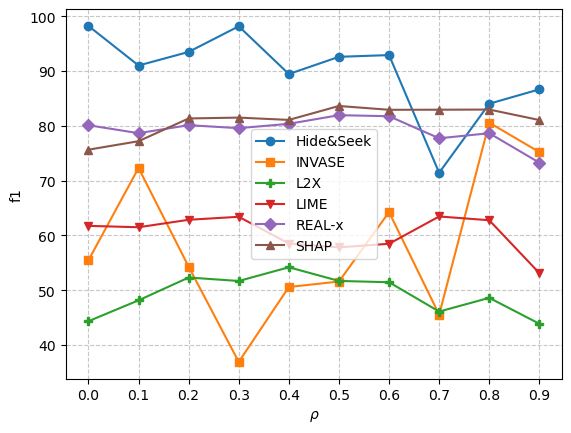

In [160]:
query = 'pct_sig<1.5' #irrelevant

best_roc = (
    a.query(query)
     .loc[
         lambda df: df.groupby(['model', 'rho'])['roc_auc'].idxmax()
     ]
).reset_index()

best_roc = pd.concat([best_roc,
                      shap_best_configs_per_rho[list(best_roc.columns)]])

import matplotlib.pyplot as plt


# Accessible combinations: markers and linestyles
markers = itertools.cycle(['o', 's', 'P','v', 'D', '^'])

df = best_roc.reset_index()

plt.figure()

for model, g in df.query('rho!=1').groupby('model'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers), 
        markersize=6, 
        label=model
    )


plt.xlabel(r'$\rho$')
plt.ylabel('f1')
plt.xticks(np.arange(0, 1, 0.1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

We can see that just taking the best auroc is not as kind to the other models.

switch accuracy for syn4,5,6

In [137]:
# 1. Isolate the exact combinations you want to keep
filter_df = best_roc[['model', 'rho', 'lmbda']]

# 2. Filter 'temp' by performing an inner merge
filtered_temp = temp[['model', 'rho', 'f1','lmbda','syn','switch_accuracy']].merge(filter_df, on=['model', 'rho', 'lmbda'], how='inner')
filtered_temp['syn'] = filtered_temp['syn'].str[-1].astype(int)
filtered_temp.query('syn>=4').groupby(['model','rho']).mean()

f1  lmbda  syn  switch_accuracy
model     rho                                        
Hide&Seek 0.0  97.123893   0.30  5.0         0.997800
          0.1  82.054208   0.10  5.0         1.000000
          0.2  86.950876   0.10  5.0         0.999367
          0.3  96.830551   0.30  5.0         0.999900
          0.4  79.703666   0.10  5.0         1.000000
          0.5  85.171695   0.10  5.0         1.000000
          0.6  85.826169   0.10  5.0         0.999800
          0.7  60.678309   0.05  5.0         1.000000
          0.8  74.072342   0.05  5.0         1.000000
          0.9  79.602137   0.05  5.0         0.999733
          1.0  37.821826   0.05  5.0         0.695367
INVASE    0.0  52.299525   0.30  5.0         0.000000
          0.1  52.952056   0.30  5.0         0.059467
          0.2  50.685057   0.30  5.0         0.204500
          0.3  23.500418   0.50  5.0         0.000000
          0.4  49.744143   0.30  5.0         0.352067
          0.5  47.152456   0.30  5.0         0.369867
          0.6  44.272663   0.30  5.0         0.367567
          0.7  40.588673   0.30  5.0         0.336000
          0.8  64.818303   0.05  5.0         0.786433
          0.9  53.312760   0.05  5.0         0.843933
          1.0  16.971379   0.05  5.0         0.203500
L2X       0.0  45.259500   0.10  5.0         0.577467
          0.1  46.960000   0.10  5.0         0.557200
          0.2  48.551833   0.10  5.0         0.577767
          0.3  49.451000   0.10  5.0         0.546533
          0.4  50.516000   0.10  5.0         0.613167
          0.5  50.240667   0.10  5.0         0.570533
          0.6  47.816333   0.10  5.0         0.562900
          0.7  44.035833   0.10  5.0         0.554500
          0.8  46.944167   0.10  5.0         0.537900
          0.9  46.110333   0.10  5.0         0.555500
          1.0  52.991167   0.10  5.0         0.581600
LIME      0.0  49.586167   0.10  5.0         0.178833
          0.1  48.883000   0.10  5.0         0.156200
          0.2  49.058667   0.10  5.0         0.195500
          0.3  52.391333   0.10  5.0         0.285333
          0.4  48.173500   0.10  5.0         0.210100
          0.5  49.551333   0.10  5.0         0.339267
          0.6  50.655667   0.10  5.0         0.372067
          0.7  57.889833   0.10  5.0         0.674700
          0.8  60.217833   0.10  5.0         0.936167
          0.9  52.220833   0.10  5.0         0.875467
          1.0  44.617333   0.10  5.0         0.314767
REAL-x    0.0  74.962686   0.05  5.0         1.000000
          0.1  73.552932   0.05  5.0         1.000000
          0.2  75.742004   0.05  5.0         1.000000
          0.3  76.396711   0.05  5.0         1.000000
          0.4  74.175090   0.05  5.0         1.000000
          0.5  76.047849   0.05  5.0         1.000000
          0.6  73.315975   0.05  5.0         1.000000
          0.7  71.506701   0.05  5.0         0.967167
          0.8  65.907951   0.05  5.0         0.992367
          0.9  62.108189   0.05  5.0         0.992533
          1.0  21.958637   0.05  5.0         0.261000